# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [2]:
!pip install numpy==1.26.4 gymnasium minatar torch

In [3]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [4]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [ ]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1)
    ball_pos = np.where(ball_channel == 1)

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean()
    ball_x = ball_pos[1].mean()

    if ball_x < paddle_x:
        return 1
    elif ball_x > paddle_x:
        return 2
    else:
        return 0

In [6]:
def run_episode(env, policy_fn):
    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps


def evaluate_policy(env, policy_fn, num_episodes=100):
    rewards = []
    steps_list = []

    for _ in range(num_episodes):
        total_reward, steps = run_episode(env, policy_fn)
        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [7]:
env = gym.make("MinAtar/Breakout-v1")
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [8]:
num_episodes = 100

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.31 +/- 0.56
  Steps:  9.18 +/- 5.85

Heuristic Policy:
  Reward: 10.16 +/- 10.12
  Steps:  118.86 +/- 118.59


In [57]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

observations = []
rewards = []

def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        observations.append(observation)
        rewards.append(reward)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 17, Steps = 192


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

2. **Action space**: What actions are available? How do they affect the game state?

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

Visualize observations, reward distributions, and episode statistics to support your analysis.

### _Answers_
1.

Observation shape: (10, 10, 4)


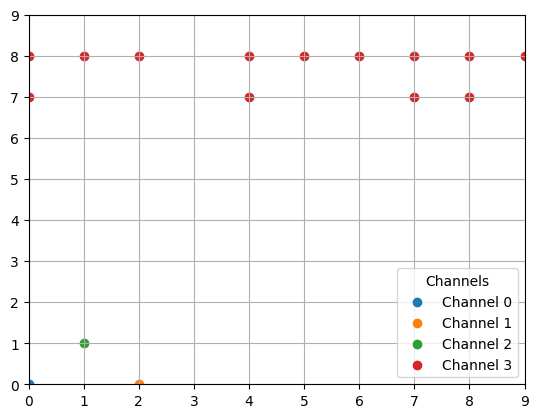

In [85]:
obs = observations[-1]
print(f"Observation shape: {obs.shape}")
for channel in range(obs.shape[2]):
    X = np.where(obs[:,:,channel]==1)[1]
    Y = 9 - np.where(obs[:,:,channel]==1)[0]
    coords = np.stack((X, Y), axis=-1)
    plt.scatter(X, Y, label=f"Channel {channel}")
    if channel == obs.shape[2] - 1:
        plt.legend(title="Channels")
plt.xlim(0,9)
plt.ylim(0,9)
plt.grid()
plt.show()

**Answer**: As demonstrated by the code above, observations have shape $(10,10,4)$:
- 1st dimension: Y coordinate, top to bottom
- 2nd dimension: X coordinate, left to right
- 3rd dimension: 0 for paddle, 1 for ball's head, 2 for ball's tail, 3 for bricks
When ignoring the constraints such as restricted positions, no intersection, ball's continuity, etc, we have  $$|\mathcal{X}|=10*10*4=400$$
2. There is 3 actions available:
- $a=0$: do nothing
- $a=1$: go right $\Rightarrow$ paddle's x coordinate incremented of 1 if possible
- $a=2$: go left $\Rightarrow$ paddle's x coordinate decremented of 1 if possible
3.

In [86]:
steps_with_reward = np.where(np.array(rewards) == 1)[0]
print(f"Steps with reward = 1: {steps_with_reward}")
avg_reward_per_step = np.sum(rewards) / (np.arange(len(rewards)) + 1)
print(f"Average reward per step: {avg_reward_per_step[-1]:.4f}")
gap_between_rewards = np.diff(steps_with_reward)
print(f"Steps between rewards: mean: {gap_between_rewards.mean():.2f}, min: {gap_between_rewards.min()}, max: {gap_between_rewards.max()}")

print(f"Heuristic reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")

Steps with reward = 1: [ 10  20  31  42  52  63  74  84  95 106 116 127 138 148 159 172 185]
Average reward per step: 0.0885
Steps between rewards: mean: 10.94, min: 10, max: 13
Heuristic reward: 10.16 +/- 10.12


**Answer**: Agent receives reward $1$ every time a brick breaks. It receives one about every $10.67$ steps, 10 to 13 depending on how far the ball went through the brick layers.

When playing the heuristic, the agent's typical return is $10.16 \pm 10.12$.

4. What causes an episode to end is either
- ball falls to the ground _i.e._ ball's head y-coordinate is 9 _i.e._ ```observation[8, :, 1].any() is True```
- all bricks are broken _i.e._ ```observation[:, :, 3].any() is False```

5. The environment is deterministic: the ball always bounces the same way. The only source of randomness is initial state of ball and paddle but it's not considered part of the environment.

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.